## Sessão de AI tradicional
### treinando um modelo preditivo da copa do mundo 2026 

Neste notebook você vai ver, passo a passo:
- preparação dos dados
- cálculo de ELO (força dos times)
- treino de modelos (resultado + gols)
- avaliação usando a Copa do Mundo 2022
- geração de previsões a partir de dois times

Tudo organizado de forma simples para rodar célula a célula.

### Setup

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_absolute_error

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression

import joblib
import os

### Carregar e limpar dados

In [2]:
def load_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path, encoding="cp1252")


def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df.columns = df.columns.str.strip().str.replace(" ", "_")

    df["Match_Date"] = pd.to_datetime(df["Match_Date"], errors="coerce")
    df["Year"] = df["Match_Date"].dt.year

    numeric_cols = [
        "Home_Team_Score",
        "Away_Team_Score",
        "Home_Team_Win",
        "Away_Team_Win",
        "Draw"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    return df


df = load_data("data/worldcup_matches.csv")
df = basic_cleaning(df)

df.head()

,Key_Id,Tournament_Id,tournament_Name,Match_Id,Match_Name,Stage_Name,Group_Name,Group_Stage,Knockout_Stage,Replayed,...,Extra_Time,Penalty_Shootout,Score_Penalties,Home_Team_Score_Penalties,Away_Team_Score_Penalties,Result,Home_Team_Win,Away_Team_Win,Draw,Year
0,1,WC-1930,1930 FIFA World Cup,M-1930-01,France v Mexico,group stage,Group 1,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,1930
1,2,WC-1930,1930 FIFA World Cup,M-1930-02,United States v Belgium,group stage,Group 4,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,1930
2,3,WC-1930,1930 FIFA World Cup,M-1930-03,Yugoslavia v Brazil,group stage,Group 2,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,1930
3,4,WC-1930,1930 FIFA World Cup,M-1930-04,Romania v Peru,group stage,Group 3,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,1930
4,5,WC-1930,1930 FIFA World Cup,M-1930-05,Argentina v France,group stage,Group 1,1,0,0,...,0,0,0-0,0,0,home team win,1,0,0,1930


### Feature Engeneering (ELO)

In [3]:
def expected_score(rating_a, rating_b):
    return 1 / (1 + 10 ** ((rating_b - rating_a) / 400))


def update_elo(rating, expected, actual, k=30):
    return rating + k * (actual - expected)


def compute_elo(df: pd.DataFrame, k=30):

    df = df.sort_values("Match_Date").copy()

    ratings = {}
    elo_home = []
    elo_away = []

    for _, row in df.iterrows():

        home = row["Home_Team_Name"]
        away = row["Away_Team_Name"]

        ratings.setdefault(home, 1500)
        ratings.setdefault(away, 1500)

        rating_home = ratings[home]
        rating_away = ratings[away]

        elo_home.append(rating_home)
        elo_away.append(rating_away)

        expected_home = expected_score(rating_home, rating_away)
        expected_away = expected_score(rating_away, rating_home)

        if row["Home_Team_Win"] == 1:
            actual_home, actual_away = 1, 0
        elif row["Away_Team_Win"] == 1:
            actual_home, actual_away = 0, 1
        else:
            actual_home = actual_away = 0.5

        ratings[home] = update_elo(rating_home, expected_home, actual_home, k)
        ratings[away] = update_elo(rating_away, expected_away, actual_away, k)

    df["elo_home"] = elo_home
    df["elo_away"] = elo_away
    df["elo_diff"] = df["elo_home"] - df["elo_away"]

    return df, ratings


df, ratings = compute_elo(df)

In [4]:
def create_team_features(df: pd.DataFrame):

    goals_for = pd.concat([
        df[["Home_Team_Name", "Home_Team_Score"]].rename(
            columns={"Home_Team_Name": "Team", "Home_Team_Score": "Goals_For"}
        ),
        df[["Away_Team_Name", "Away_Team_Score"]].rename(
            columns={"Away_Team_Name": "Team", "Away_Team_Score": "Goals_For"}
        )
    ])

    goals_against = pd.concat([
        df[["Home_Team_Name", "Away_Team_Score"]].rename(
            columns={"Home_Team_Name": "Team", "Away_Team_Score": "Goals_Against"}
        ),
        df[["Away_Team_Name", "Home_Team_Score"]].rename(
            columns={"Away_Team_Name": "Team", "Home_Team_Score": "Goals_Against"}
        )
    ])

    wins = pd.concat([
        df[["Home_Team_Name", "Home_Team_Win"]].rename(
            columns={"Home_Team_Name": "Team", "Home_Team_Win": "Win"}
        ),
        df[["Away_Team_Name", "Away_Team_Win"]].rename(
            columns={"Away_Team_Name": "Team", "Away_Team_Win": "Win"}
        )
    ])

    team_stats = goals_for.groupby("Team").mean()
    team_stats["avg_goals_against"] = goals_against.groupby("Team").mean()
    team_stats["win_rate"] = wins.groupby("Team").mean()

    return team_stats.fillna(0)


team_stats = create_team_features(df)

In [5]:
def add_match_features(df, team_stats):

    df = df.copy()

    df = df.merge(
        team_stats,
        left_on="Home_Team_Name",
        right_index=True,
        how="left"
    ).rename(columns={
        "Goals_For": "teamA_avg_goals",
        "avg_goals_against": "teamA_avg_conceded",
        "win_rate": "teamA_win_rate"
    })

    df = df.merge(
        team_stats,
        left_on="Away_Team_Name",
        right_index=True,
        how="left",
        suffixes=("", "_B")
    ).rename(columns={
        "Goals_For": "teamB_avg_goals",
        "avg_goals_against": "teamB_avg_conceded",
        "win_rate": "teamB_win_rate"
    })

    df["goals_diff"] = df["teamA_avg_goals"] - df["teamB_avg_goals"]
    df["defense_diff"] = df["teamA_avg_conceded"] - df["teamB_avg_conceded"]
    df["win_rate_diff"] = df["teamA_win_rate"] - df["teamB_win_rate"]

    return df


df = add_match_features(df, team_stats)

### Preparar dataset

In [6]:
def prepare_training_data(df: pd.DataFrame):

    features = [
        "elo_diff",
        "goals_diff",
        "defense_diff",
        "win_rate_diff"
    ]

    X = df[features]

    df["match_result"] = (
        df["Home_Team_Win"] * 1 +
        df["Away_Team_Win"] * 2
    )

    y_result = df["match_result"]
    y_home_goals = df["Home_Team_Score"]
    y_away_goals = df["Away_Team_Score"]

    return X, y_result, y_home_goals, y_away_goals

X, y_result, y_home, y_away = prepare_training_data(df)

### Treinar modelos

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_result, test_size=0.2, random_state=42
)

models = {}

# Modelo 1 - Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

models["rf"] = rf_model

# Modelo 2 - Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

models["logistic"] = log_model

### Avaliar modelos

In [8]:
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f}")

rf: 0.5596
logistic: 0.6010


### Modelo de gols

In [9]:
home_goals_model = RandomForestRegressor()
home_goals_model.fit(X, y_home)

away_goals_model = RandomForestRegressor()
away_goals_model.fit(X, y_away)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### Teste com copa 2022

In [10]:
df_2022 = df[df["Year"] == 2022]

X_2022 = df_2022[["elo_diff", "goals_diff", "defense_diff", "win_rate_diff"]]
y_2022 = df_2022["match_result"]

model = models["rf"]

preds_2022 = model.predict(X_2022)

print("Accuracy Copa 2022:", accuracy_score(y_2022, preds_2022))

Accuracy Copa 2022: 0.859375


In [11]:
%%capture
!pip install matplotlib shap --no-cache-dir

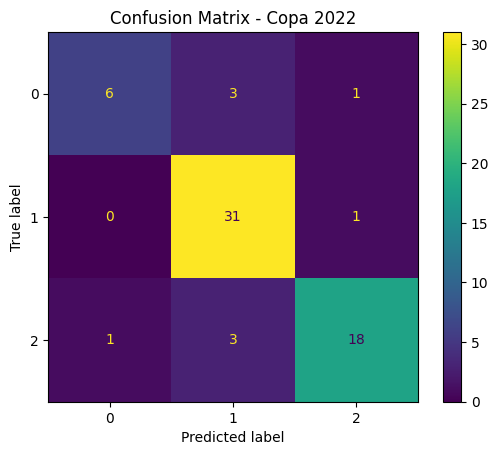

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_2022, preds_2022)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Copa 2022")
plt.show()

### Função de inferência

In [13]:
def predict_match(home_team, away_team, ratings, team_stats, model):

    # --- ELO ---
    rating_home = ratings.get(home_team, 1500)
    rating_away = ratings.get(away_team, 1500)

    elo_diff = rating_home - rating_away

    # --- stats time A ---
    if home_team in team_stats.index:
        teamA = team_stats.loc[home_team]
    else:
        teamA = {"Goals_For": 1.2, "avg_goals_against": 1.2, "win_rate": 0.5}

    # --- stats time B ---
    if away_team in team_stats.index:
        teamB = team_stats.loc[away_team]
    else:
        teamB = {"Goals_For": 1.2, "avg_goals_against": 1.2, "win_rate": 0.5}

    # --- novas features ---
    goals_diff = teamA["Goals_For"] - teamB["Goals_For"]
    defense_diff = teamA["avg_goals_against"] - teamB["avg_goals_against"]
    win_rate_diff = teamA["win_rate"] - teamB["win_rate"]

    # --- dataframe final (mesma ordem do treino!) ---
    features = pd.DataFrame([{
        "elo_diff": elo_diff,
        "goals_diff": goals_diff,
        "defense_diff": defense_diff,
        "win_rate_diff": win_rate_diff
    }])

    # --- previsão ---
    probs = model.predict_proba(features)[0]

    home_goals = home_goals_model.predict(features)[0]
    away_goals = away_goals_model.predict(features)[0]

    return {
        "home_win": probs[1],
        "draw": probs[0],
        "away_win": probs[2],
        "home_goals": home_goals,
        "away_goals": away_goals
    }

### Prove Brasil e França e veja qual percentual de chance do Brasil ganhar?

In [19]:
predict_match("Brasil", "Argentina", ratings, team_stats, models["rf"])

{'home_win': np.float64(0.33),
 'draw': np.float64(0.4),
 'away_win': np.float64(0.27),
 'home_goals': np.float64(1.05),
 'away_goals': np.float64(1.14)}